# Gender Gap in Education Enrollment — Pakistan & South Asia
### Part 3: Tracking the Gender Gap Across Primary, Secondary, and Tertiary Education

**By Mahma Rani**

This project examines the gender gap in education enrollment in Pakistan, and compares it to neighboring South Asian countries, across three education levels: primary, secondary, and tertiary. The goal is to understand not just whether a gap exists, but **how it has changed over time**, and whether Pakistan's trajectory matches the regional pattern.

**Dataset:** Global Education dataset (male/female enrollment rates by country and year), via Kaggle.


## Step 1: Load the Data and Filter for Pakistan

The dataset contains enrollment rates broken down by gender for primary, secondary, and tertiary education, across many countries and years. The first step is to isolate Pakistan's data and inspect its structure.

In [4]:
import pandas as pd 
df= pd.read_csv("C:\\Users\\Adel computers\\Downloads\\4gender-gap-education-levels.csv")
df4_pakistan = df[df['Entity'] == 'Pakistan']
print(df4_pakistan)


        Entity Code  Year  \
6404  Pakistan  PAK  1986   
6405  Pakistan  PAK  1987   
6406  Pakistan  PAK  1988   
6407  Pakistan  PAK  1990   
6408  Pakistan  PAK  1992   
6409  Pakistan  PAK  2003   
6410  Pakistan  PAK  2004   
6411  Pakistan  PAK  2005   
6412  Pakistan  PAK  2006   
6413  Pakistan  PAK  2007   
6414  Pakistan  PAK  2008   
6415  Pakistan  PAK  2009   
6416  Pakistan  PAK  2010   
6417  Pakistan  PAK  2011   
6418  Pakistan  PAK  2012   
6419  Pakistan  PAK  2013   
6420  Pakistan  PAK  2014   
6421  Pakistan  PAK  2015   
6422  Pakistan  PAK  2016   
6423  Pakistan  PAK  2017   
6424  Pakistan  PAK  2018   
6425  Pakistan  PAK  2019   
6426  Pakistan  PAK  1820   
6427  Pakistan  PAK  1825   
6428  Pakistan  PAK  1830   
6429  Pakistan  PAK  1835   
6430  Pakistan  PAK  1840   
6431  Pakistan  PAK  1845   
6432  Pakistan  PAK  1850   
6433  Pakistan  PAK  1855   
6434  Pakistan  PAK  1860   
6435  Pakistan  PAK  1865   
6436  Pakistan  PAK  1870   
6437  Pakistan

In [5]:
df4_pakistan = df[df['Entity'] == 'Pakistan']
print(df4_pakistan.shape)
df4_pakistan.head(10)

(56, 9)


,Entity,Code,Year,"Combined gross enrolment ratio for tertiary education, female","Combined gross enrolment ratio for tertiary education, male","Combined total net enrolment rate, secondary, male","Combined total net enrolment rate, secondary, female","Combined total net enrolment rate, primary, female","Combined total net enrolment rate, primary, male"
6404,Pakistan,PAK,1986,1.60756,4.30359,NaN,NaN,NaN,NaN
6405,Pakistan,PAK,1987,1.57386,4.26882,NaN,NaN,NaN,NaN
6406,Pakistan,PAK,1988,1.84937,4.76938,NaN,NaN,NaN,NaN
6407,Pakistan,PAK,1990,1.75653,4.33021,NaN,NaN,NaN,NaN
6408,Pakistan,PAK,1992,0.89028,3.31290,NaN,NaN,NaN,NaN
6409,Pakistan,PAK,2003,2.39876,2.98606,NaN,NaN,47.51588,65.39431
6410,Pakistan,PAK,2004,2.97862,3.77907,NaN,NaN,51.92799,70.85186
6411,Pakistan,PAK,2005,4.57152,5.25631,NaN,NaN,54.86775,71.37359
6412,Pakistan,PAK,2006,4.56527,5.38487,34.26988,26.53007,53.48415,67.58697
6413,Pakistan,PAK,2007,5.14005,6.06515,36.92050,27.99058,58.72754,70.48295


## Step 2: Calculate the Gender Gap at Each Education Level

To measure the gap directly, a new column is created for each education level: **Male enrollment % − Female enrollment %**. A positive value means more males are enrolled than females; a negative value means the reverse — more females enrolled than males.

In [8]:
df4_pakistan['Primary_Gap'] = df4_pakistan['Combined total net enrolment rate, primary, male'] - df4_pakistan['Combined total net enrolment rate, primary, female']
df4_pakistan['Secondary_Gap'] = df4_pakistan['Combined total net enrolment rate, secondary, male'] - df4_pakistan['Combined total net enrolment rate, secondary, female']
df4_pakistan['Tertiary_Gap'] = df4_pakistan['Combined gross enrolment ratio for tertiary education, male'] - df4_pakistan['Combined gross enrolment ratio for tertiary education, female']

## Step 3: Data Quality Check — Removing Pre-1947 Records

Inspecting the data revealed entries for "Pakistan" dating back to 1820 — over a century before Pakistan existed as a country (founded in 1947). These early records also showed suspiciously clean, round values (e.g. exactly 0.01, 0.02), suggesting they are either placeholder values or estimates incorrectly attributed to Pakistan. These rows were removed, since a country's education data cannot meaningfully exist before the country itself does.

In [9]:
df4_pakistan = df4_pakistan[df4_pakistan['Year'] >= 1947]

## Step 4: Further Filtering — Keeping Only Consistent, Reliable Years

Even after removing pre-1947 data, the remaining records from 1950–1980 showed a different statistical pattern than the 2003 onward data (unusually high values, irregular gaps between years), suggesting they may come from a different source or estimation method with lower reliability.

To keep the analysis grounded in consistent, comparable data, the analysis focuses on **2003 onward**, which has regular yearly coverage and values consistent with verified modern enrollment statistics.

In [10]:
df4_pakistan = df4_pakistan[df4_pakistan['Year'] >= 2003]

## Step 5: Visualize Pakistan's Gender Gap Across Education Levels (2003–2018)

With clean data in place, the three gap measures (Primary, Secondary, Tertiary) are plotted together to compare how the gender gap has evolved at each level over time. A horizontal line at zero marks the point where enrollment is equal between genders.

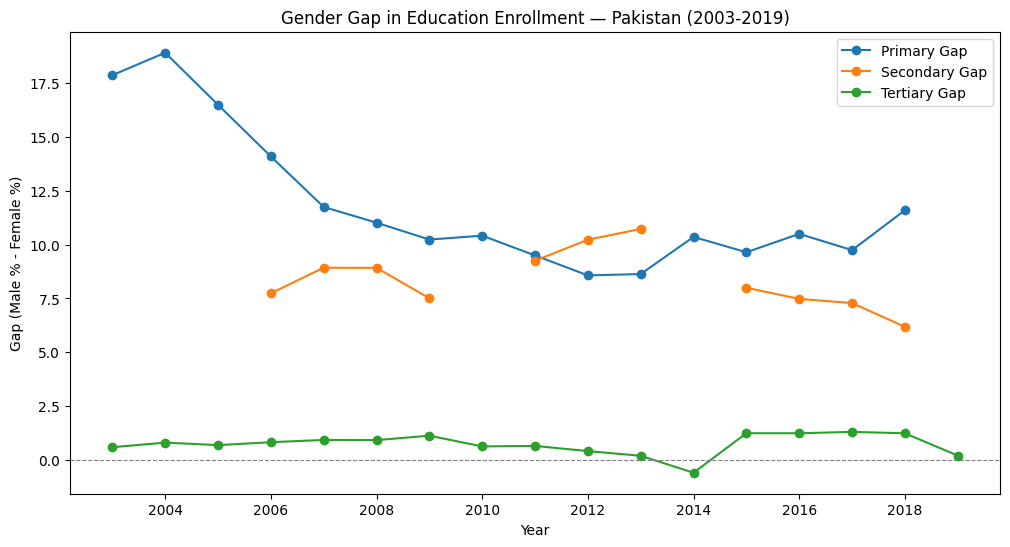

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df4_pakistan['Year'], df4_pakistan['Primary_Gap'], marker='o', label='Primary Gap')
plt.plot(df4_pakistan['Year'], df4_pakistan['Secondary_Gap'], marker='o', label='Secondary Gap')
plt.plot(df4_pakistan['Year'], df4_pakistan['Tertiary_Gap'], marker='o', label='Tertiary Gap')
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Gender Gap in Education Enrollment — Pakistan (2003-2019)')
plt.xlabel('Year')
plt.ylabel('Gap (Male % - Female %)')
plt.legend()
plt.show()

### Interpretation

- **Primary education** shows the largest and most volatile gap. It declined steadily from ~17.9 points (2003) to a low of ~8.6 points (2013) — genuine progress — but then **reversed**, climbing back up to ~11.6 points by 2018. This is not a simple improving trend; it's closer to a U-shape, with progress stalling and partially reversing after 2013.
- **Secondary education** shows a smaller, more moderate gap (roughly 6–11 points), broadly following a similar pattern — some narrowing in recent years (2015–2018), though less dramatic than the reversal seen in Primary.
- **Tertiary education** stays remarkably close to zero throughout the entire period (mostly between 0.2 and 1.3 points), even briefly going negative in 2014 (women slightly ahead). At first glance this looks like near gender parity at the university level.

**Important nuance:** A small gender gap at the tertiary level does not mean equal opportunity — it likely reflects a "selection effect." Since overall tertiary enrollment in Pakistan is very low (under 13% for both genders across this period), the small group of women who do reach university tend to come from families where gender bias is already lower. The real, larger gap is at the primary and secondary level, where a much bigger share of the population is affected — this is where the most girls are leaving the education system relative to boys.

## Step 6: Expand the Comparison to South Asia

To see whether Pakistan's pattern is typical for the region or distinct from it, the same gap calculations are applied to neighboring countries: India, Bangladesh, Afghanistan, Nepal, and Sri Lanka.

In [12]:
countries = ['Pakistan', 'India', 'Bangladesh', 'Afghanistan', 'Nepal', 'Sri Lanka']
df4_south_asia = df[df['Entity'].isin(countries)]
df4_south_asia.shape

(342, 9)

## Step 7: Apply the Same Data Quality Filter (2003 onward) Across All Countries

The same pre-2003 data quality issue found in Pakistan's records turned out to affect all six countries in this dataset, confirming it's a dataset-wide structural issue rather than something specific to Pakistan. The same 2003 cutoff is applied consistently across all countries for a fair comparison.

In [14]:
df4_south_asia = df4_south_asia[df4_south_asia['Year'] >= 2003]
df4_south_asia.groupby('Entity')['Year'].agg(['min', 'max', 'count'])

,min,max,count
Entity,,,
Afghanistan,2003,2020,12
Bangladesh,2003,2021,19
India,2003,2021,19
Nepal,2003,2021,17
Pakistan,2003,2019,17
Sri Lanka,2003,2020,17


## Step 8: Calculate Gender Gaps for All Countries

In [15]:
df4_south_asia['Primary_Gap'] = df4_south_asia['Combined total net enrolment rate, primary, male'] - df4_south_asia['Combined total net enrolment rate, primary, female']
df4_south_asia['Secondary_Gap'] = df4_south_asia['Combined total net enrolment rate, secondary, male'] - df4_south_asia['Combined total net enrolment rate, secondary, female']
df4_south_asia['Tertiary_Gap'] = df4_south_asia['Combined gross enrolment ratio for tertiary education, male'] - df4_south_asia['Combined gross enrolment ratio for tertiary education, female']

## Step 9: Initial Comparison — and a Data Quality Red Flag

Looking at each country's most recent recorded gap produced some striking, almost reversed results — several countries appeared to show negative gaps (girls ahead of boys), which prompted a closer look before trusting the numbers.

In [16]:
df4_south_asia.groupby('Entity')[['Primary_Gap', 'Secondary_Gap', 'Tertiary_Gap']].last()

,Primary_Gap,Secondary_Gap,Tertiary_Gap
Entity,,,
Afghanistan,NaN,25.95916,9.227850
Bangladesh,-2.15447,-5.41687,4.560529
India,-1.63366,-1.45925,-2.391690
Nepal,11.18517,5.60943,-1.728167
Pakistan,11.60221,6.18290,0.198250
Sri Lanka,1.26094,-2.43391,-10.146560


### Investigating Bangladesh's Surprising Result

Bangladesh's Primary_Gap appeared strongly negative when looking only at the most recent value. Inspecting the raw enrollment numbers revealed why: Bangladesh has **only one year (2008)** of non-missing primary enrollment data in this dataset. A single data point cannot represent a "trend" — using `.last()` on a column with mostly missing values risks treating an isolated, possibly unusual year as if it were a reliable recent pattern. This is the same kind of caution that uncovered the BMI=0 error in the maternal health clinical dataset (Part 2 of this project) — a reminder to verify any value before treating it as meaningful, especially data points that contradict expectations.

In [ ]:
df4_south_asia[df4_south_asia['Entity'] == 'Bangladesh'][['Year', 'Combined total net enrolment rate, primary, male', 'Combined total net enrolment rate, primary, female']]

,Year,"Combined total net enrolment rate, primary, male","Combined total net enrolment rate, primary, female"
602,2003,NaN,NaN
603,2004,NaN,NaN
604,2005,NaN,NaN
605,2006,NaN,NaN
606,2007,NaN,NaN
607,2008,91.5114,93.66587
608,2009,NaN,NaN
609,2011,NaN,NaN
610,2012,NaN,NaN
611,2013,NaN,NaN


## Step 10: Checking Data Reliability Across All Countries

Since the Bangladesh issue raised concerns, the same check was extended to every country: how many actual (non-missing) data points exist for each gap measure?

In [19]:
df4_south_asia.groupby('Entity')[['Primary_Gap', 'Secondary_Gap', 'Tertiary_Gap']].count()

,Primary_Gap,Secondary_Gap,Tertiary_Gap
Entity,,,
Afghanistan,0,7,7
Bangladesh,1,14,18
India,8,1,17
Nepal,2,5,16
Pakistan,16,11,17
Sri Lanka,11,4,11


## Step 11: Applying a Reliability Threshold

A simple rule was applied: only treat a country's trend as reliable if it has **at least 10 years of data** for that measure. The results showed that data sparsity is a widespread issue — only Pakistan meets this threshold consistently across all three education levels. However, **Tertiary education** has reasonably good coverage across most countries (Bangladesh, India, Nepal, Pakistan, and Sri Lanka all qualify), making a regional tertiary-level comparison possible, even though Primary and Secondary comparisons cannot be made reliably beyond Pakistan.

In [21]:
df4_south_asia.groupby('Entity')[['Primary_Gap', 'Secondary_Gap', 'Tertiary_Gap']].count() >= 10

,Primary_Gap,Secondary_Gap,Tertiary_Gap
Entity,,,
Afghanistan,False,False,False
Bangladesh,False,True,True
India,False,False,True
Nepal,False,False,True
Pakistan,True,True,True
Sri Lanka,True,False,True


## Step 12: Visualize the Tertiary Education Gender Gap Across South Asia

With reliable data confirmed across five countries, the Tertiary_Gap trend is plotted for each to see how Pakistan's pattern compares to its neighbors.

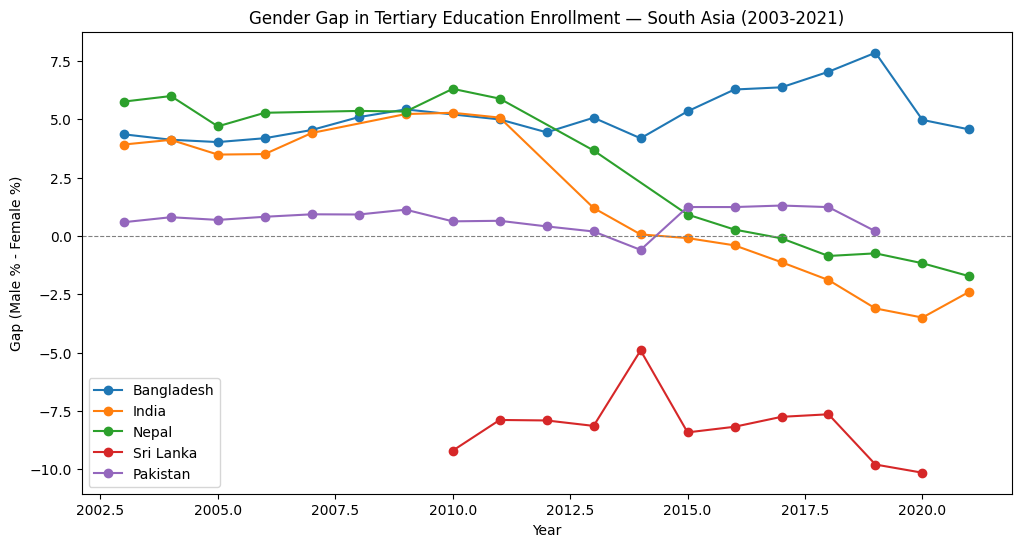

In [24]:
plt.figure(figsize=(12, 6))

for country in ['Bangladesh', 'India', 'Nepal', 'Sri Lanka', 'Pakistan']:
    country_data = df4_south_asia[df4_south_asia['Entity'] == country]
    plt.plot(country_data['Year'], country_data['Tertiary_Gap'], marker='o', label=country)

plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Gender Gap in Tertiary Education Enrollment — South Asia (2003-2021)')
plt.xlabel('Year')
plt.ylabel('Gap (Male % - Female %)')
plt.legend()
plt.show()

## Summary of Findings — Part 3

1. **Pakistan's gender gap in primary education improved from 2003 to 2013, but then partially reversed**, climbing back up by 2018 — progress is not consistent or guaranteed to continue.
2. **The tertiary education gap in Pakistan looks small, but this is misleading on its own** — Pakistan's overall tertiary enrollment is low for both genders, meaning the small gap likely reflects a privileged "selection effect" among the few who attend university, not genuine equality. The real disparity is concentrated in primary and secondary education, which affects far more of the population.
3. **Regionally, most neighboring countries have moved toward — or even reversed — the tertiary gender gap.** Nepal and Bangladesh shifted from a male-favoring gap toward a female-favoring one over the 2003–2021 period, and Sri Lanka has shown a large female-favoring gap for over a decade.
4. **Pakistan stands out as the most "stuck" country in the region at the tertiary level** — its gap has stayed close to zero throughout, neither closing meaningfully nor reversing like its neighbors.
5. **A key data quality lesson emerged during this analysis**: comparing only the most recent value per country (`.last()`) produced a misleading result for Bangladesh, which had only one valid data point for primary enrollment. This was caught by inspecting the raw numbers before trusting a surprising result — the same instinct that previously caught an invalid BMI=0 entry in Part 2 of this project.

**Connecting back to Parts 1 and 2:** This project now shows the same "progress, then stall" pattern across three different domains — maternal mortality (Part 1), individual health risk factors (Part 2), and now education access (Part 3). Pakistan's improvement in several social indicators appears to slow or reverse after the early-to-mid 2010s, a pattern that may be worth investigating further through policy or economic context outside this dataset.